In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- ecommerce_churn


In [3]:
for table in tables:
    #    print(f"\n Table: {table}")
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))

clean_dataset 5630


,customerid,churn,tenure(no_of_year_stay),login_device,citytier,warehouse_to_home,payment_mode,gender,hour_spend_on_app,number_of_device_registered,order_cat,satisfactionscore,marital_status,number_of_address,complain,order_amount_hike_from_last_year,couponused,ordercount,days_since_last_order,cashbackamount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


ecommerce_churn 5630


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [4]:
df = pd.read_sql_query(text("""select * from clean_dataset"""),engine)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customerid,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
tenure(no_of_year_stay),5630.0,10.134103,8.357951,0.0,3.00,9.0,15.00,61.0
citytier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
warehouse_to_home,5630.0,15.566785,8.345961,5.0,9.00,14.0,20.00,127.0
hour_spend_on_app,5630.0,2.934636,0.705528,0.0,2.00,3.0,3.00,5.0
number_of_device_registered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
satisfactionscore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
number_of_address,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


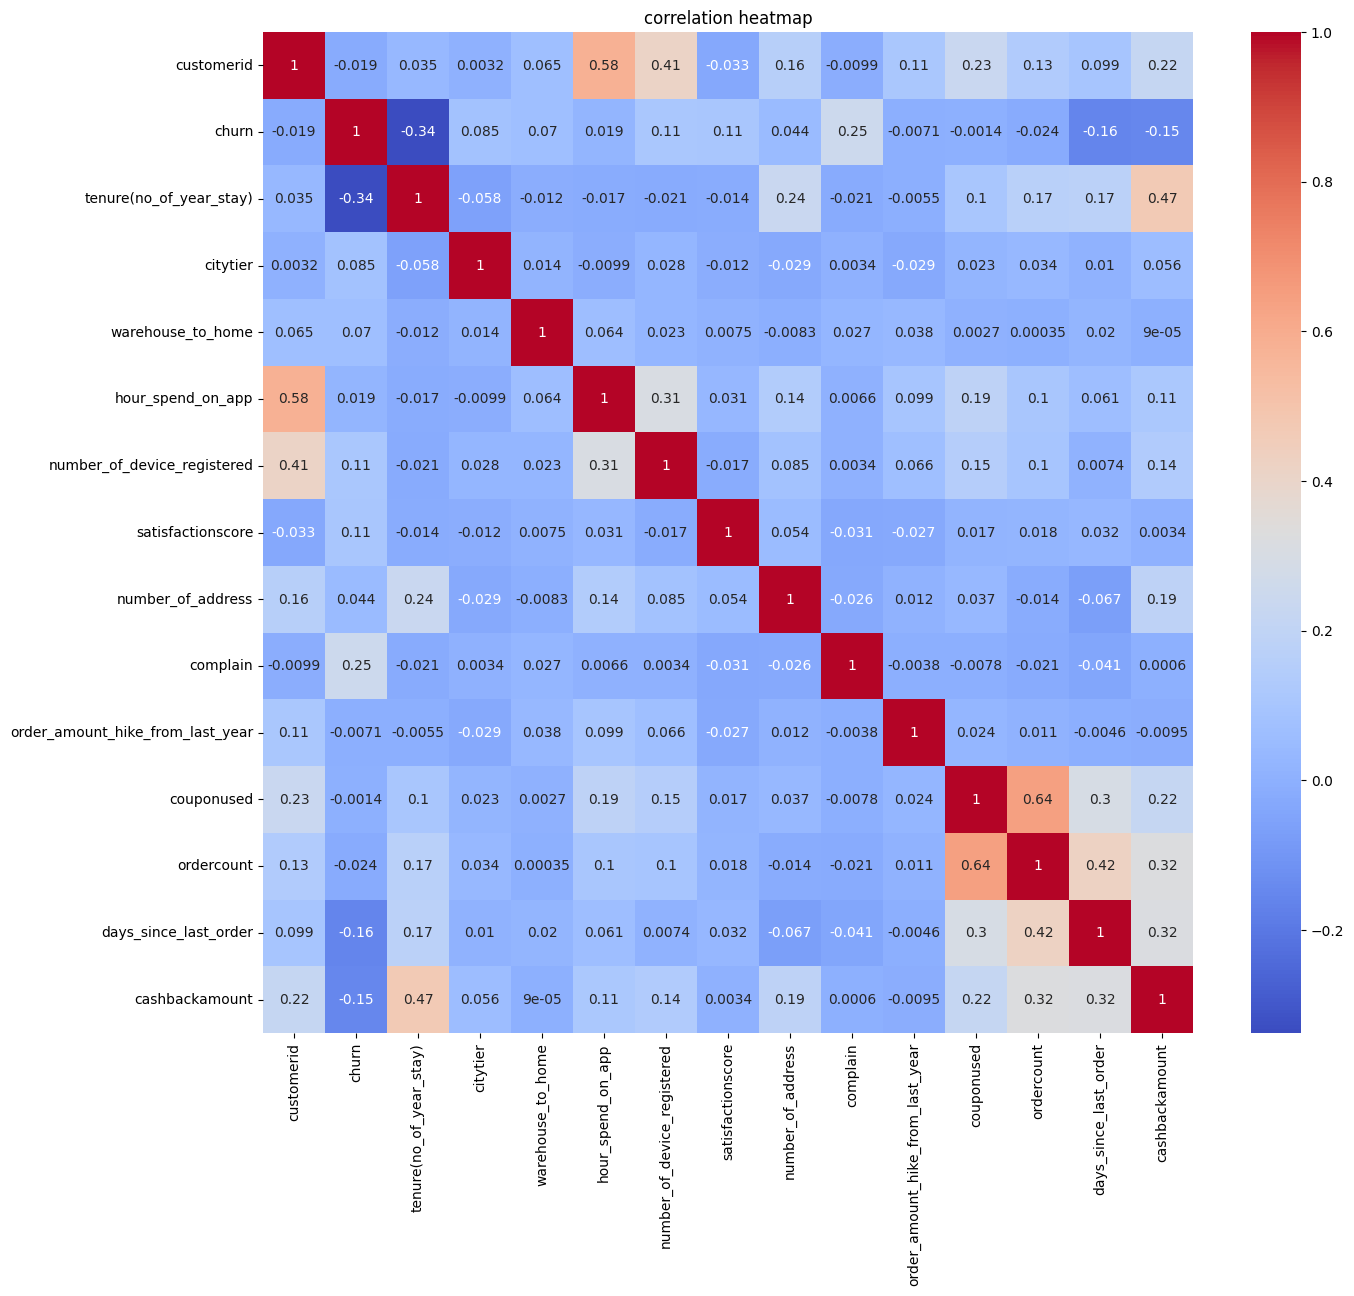

In [11]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(15,13))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

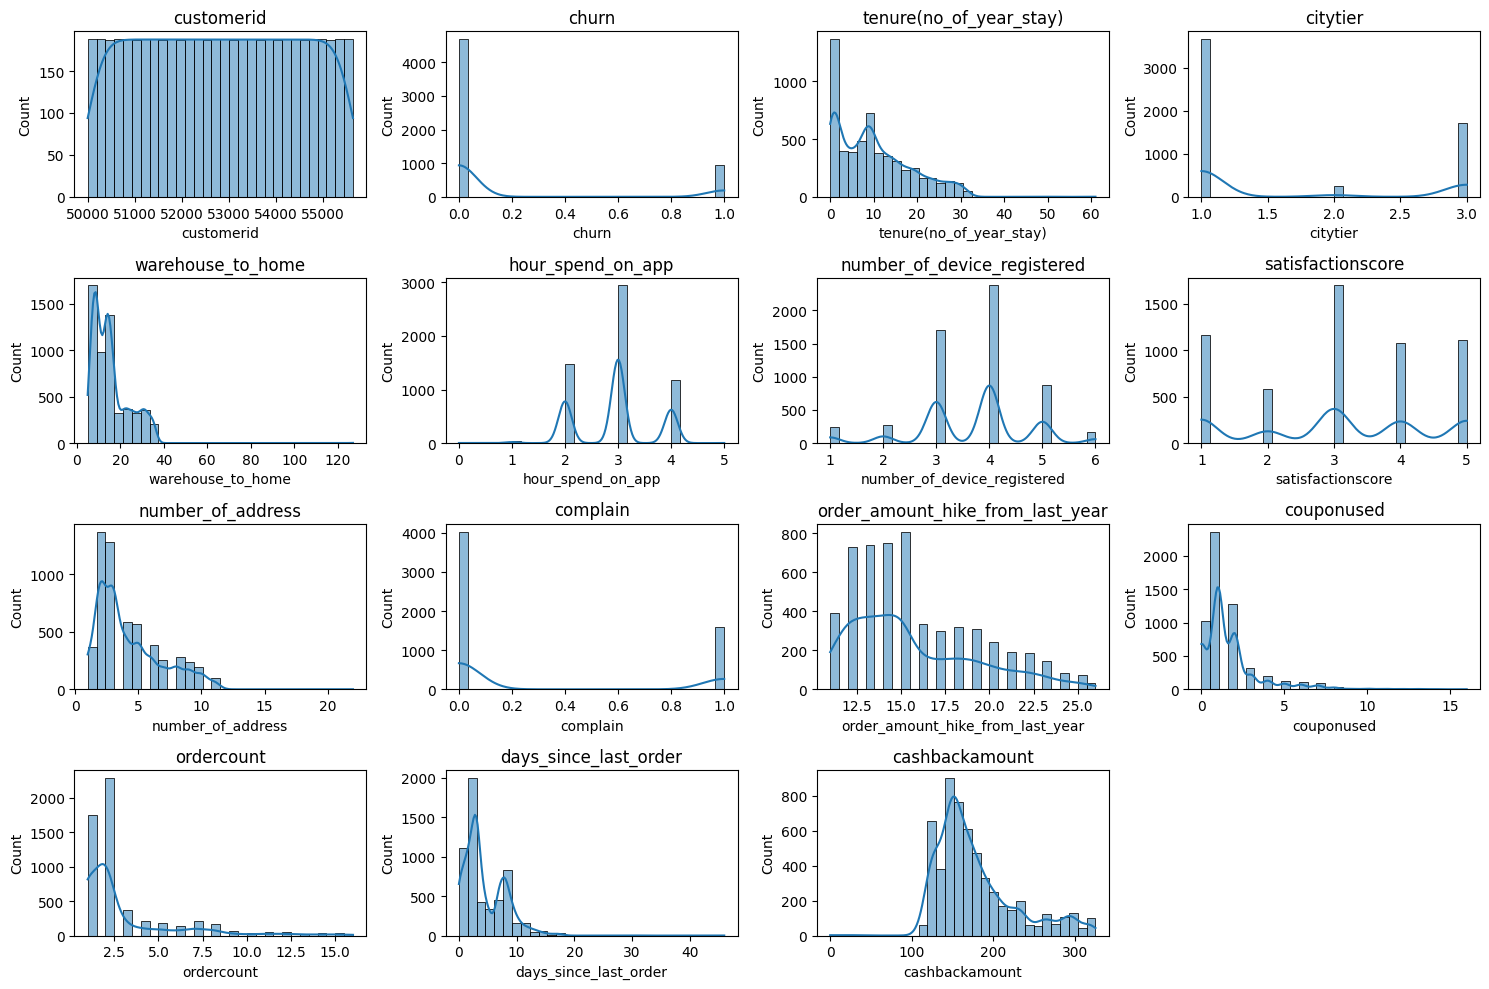

In [12]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

**as werehouse to home hasmost value accure between 0 to 50 but very few accure upper 100 ao i remove that outliers**

In [ ]:
# remove outliers from warehouse_to_home 
Q1 = df["warehouse_to_home"].quantile(0.25)
Q3 = df["warehouse_to_home"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

df = df[
    (df["warehouse_to_home"] >= lower_bound) &
    (df["warehouse_to_home"] <= upper_bound)
].copy()

print(f"Dataset shape after removing outliers: {df.shape}")

Lower Bound: -7.50
Upper Bound: 36.50
Dataset shape after removing outliers: (5628, 20)


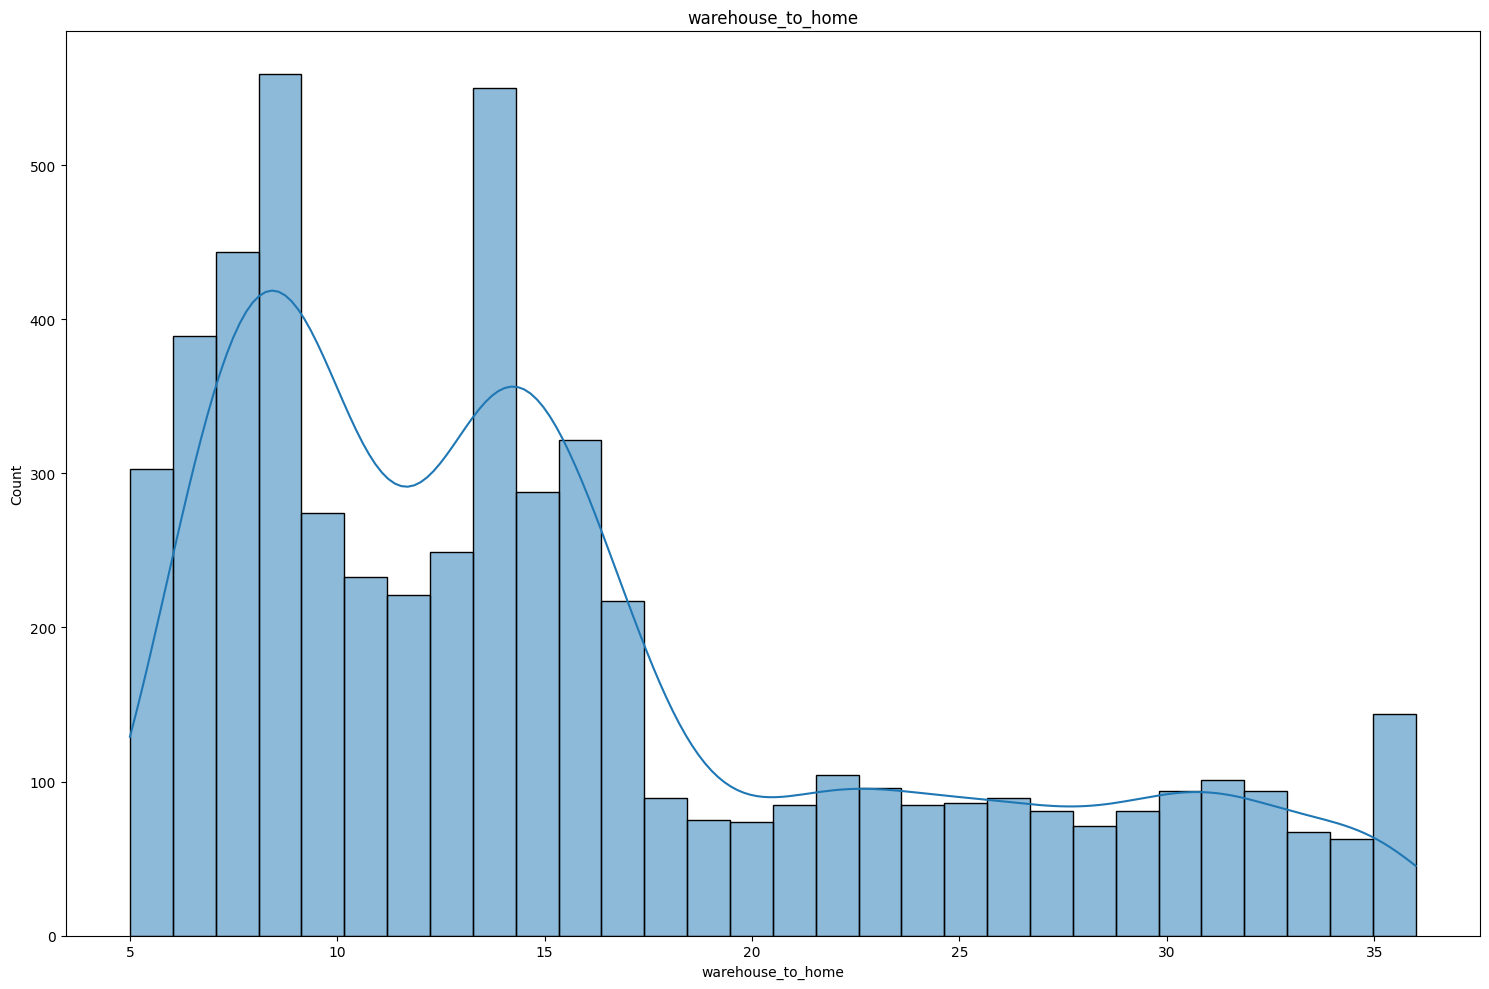

In [ ]:
numerical_cols =['warehouse_to_home']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

* sql analysis

1 . What is the overall customer churn rate?

In [32]:
churn_rate = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , count(*) as total_customer  , 
round(100.0 * count(*) / sum(count(*))over() , 2) as churn_rate from clean_dataset group by churn """),engine)
display(churn_rate)

,customer_segment,total_customer,churn_rate
0,churn,948,16.84
1,retanied,4682,83.16


2 . How does churn rate vary by CityTier?

In [18]:
city_tier_rate = pd.read_sql_query(text("""select citytier , count(*) as total_customer  , 
count(case when churn = 1 then 1 end) as total_churn , round(100.0 * count(case when churn = 1 then 1 end) 
/ count(*),2) as churn_rate 
from clean_dataset group by citytier  order by citytier"""),engine)
display(city_tier_rate)

,citytier,total_customer,total_churn,churn_rate
0,1,3666,532,14.51
1,2,242,48,19.83
2,3,1722,368,21.37


3 . How does churn rate differ by PreferredPaymentMode? — checks if payment friction (e.g., COD) drives attrition.

In [19]:
payment_method = pd.read_sql_query(text("""select payment_mode ,count(*) as total_customer , sum(churn) as total_churn , round(100.0 * count(case when churn = 1 then 1 end) 
/ count(*),2) as churn_rate from clean_dataset group by payment_mode  """),engine)
display(payment_method)

,payment_mode,total_customer,total_churn,churn_rate
0,Debit Card,2314,356.0,15.38
1,UPI,414,72.0,17.39
2,Credit Card,1774,252.0,14.21
3,Cash on Delivery,514,128.0,24.90
4,E wallet,614,140.0,22.80


4 . What's the average Tenure for churned vs. retained customers? — shows whether churn is an early-lifecycle problem.

In [33]:
avg_tenure = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(`tenure(no_of_year_stay)`),2) as avg_tenure , count(*) as total_customer from clean_dataset group by churn"""),engine)
display(avg_tenure)

,customer_segment,avg_tenure,total_customer
0,churn,3.86,948
1,retanied,11.40,4682


5 . How does average SatisfactionScore compare between churned and retained customers? — tests if dissatisfaction is a leading churn signal.

In [34]:
satisfaction = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(satisfactionscore),2) avg_satisfaction_score from clean_dataset group by churn """),engine)
display(satisfaction)

,customer_segment,avg_satisfaction_score
0,churn,3.39
1,retanied,3.00


6 . What is the churn rate by MaritalStatus? — checks if life-stage segments behave differently.

In [22]:
marital_status = pd.read_sql_query(text("""select marital_status , sum(churn) as total_churn , count(*) as total_customer  , round(100.0 * sum(churn) / count(*),2) as churn_rate  from clean_dataset group by marital_status """),engine)
display(marital_status)

,marital_status,total_churn,total_customer,churn_rate
0,Single,480.0,1796,26.73
1,Divorced,124.0,848,14.62
2,Married,344.0,2986,11.52


7 . Does raising a complaint (Complain=1) increase churn probability, and by how much? — quantifies the ROI of better complaint resolution.

In [23]:
compain_churn = pd.read_sql_query(text("""select complain , count(*) as total_customer  , sum(churn) as total_churn , round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by complain """),engine)
display(compain_churn)

,complain,total_customer,total_churn,churn_rate
0,1,1604,508.0,31.67
1,0,4026,440.0,10.93


8 . Which PreferedOrderCat has the highest churn rate? — tells the category/merchandising team where retention risk concentrates.

In [24]:
category_churn = pd.read_sql_query(text("""select order_cat , count(*) as total_customer  , sum(case when churn = 1 then 1 end) as total_churn , round(100.0 * sum(case when churn = 1 then 1 end) / count(*),2) as churn_rate from clean_dataset group by order_cat order by churn_rate desc """),engine)
display(category_churn)

,order_cat,total_customer,total_churn,churn_rate
0,Mobile Phone,1271,350.0,27.54
1,Mobile,809,220.0,27.19
2,Fashion,826,128.0,15.50
3,Laptop & Accessory,2050,210.0,10.24
4,Others,264,20.0,7.58
5,Grocery,410,20.0,4.88


9 . Is there a DaySinceLastOrder threshold beyond which churn risk spikes? — defines a trigger point for win-back campaigns.

In [25]:
last_order_churn = pd.read_sql_query(text("""select days_since_last_order ,  count(*) as total_customer  , sum(churn) as total_churn , 
round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by days_since_last_order 
order by churn_rate  """),engine)
display(last_order_churn)

,days_since_last_order,total_customer,total_churn,churn_rate
0,13.0,51,0.0,0.00
1,17.0,17,0.0,0.00
2,16.0,13,0.0,0.00
3,30.0,1,0.0,0.00
4,18.0,10,0.0,0.00
5,31.0,1,0.0,0.00
6,12.0,69,2.0,2.90
7,10.0,157,10.0,6.37
8,11.0,91,8.0,8.79
9,9.0,299,28.0,9.36


10 . How does CouponUsed differ between churned and active customers? — evaluates whether coupons actually retain customers or just get used before leaving.

In [35]:
coupon_churn = pd.read_sql_query(text("""SELECT
   case when churn = 1 then "churn" else "retanied" end as customer_segment,
    COUNT(*) AS total_customers,
    ROUND(AVG(couponused),2) AS avg_coupon_used,
    MIN(couponused) AS min_coupon_used,
    MAX(couponused) AS max_coupon_used
FROM clean_dataset
GROUP BY churn;"""),engine)
display(coupon_churn)

,customer_segment,total_customers,avg_coupon_used,min_coupon_used,max_coupon_used
0,churn,948,1.71,0.0,16.0
1,retanied,4682,1.72,0.0,16.0


11 . Does churn rate change with NumberOfDeviceRegistered? — tests if multi-device usage signals stronger platform stickiness.

In [26]:
no_of_device = pd.read_sql_query(text("""select number_of_device_registered , sum(churn) as total_churn , count(*) as total_customer  , round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by number_of_device_registered order by number_of_device_registered """),engine)
display(no_of_device)

,number_of_device_registered,total_churn,total_customer,churn_rate
0,1,22.0,235,9.36
1,2,26.0,276,9.42
2,3,254.0,1699,14.95
3,4,392.0,2377,16.49
4,5,198.0,881,22.47
5,6,56.0,162,34.57


12 . How does average CashbackAmount compare between churned and retained customers? — evaluates cashback as a loyalty lever.

In [36]:
avg_cashback = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(cashbackamount),2) as avg_cashback, count(*) as total_customer from clean_dataset group by churn """),engine)
display(avg_cashback)

,customer_segment,avg_cashback,total_customer
0,churn,160.37,948
1,retanied,180.63,4682


13 . Which combination of CityTier + PreferredPaymentMode has the highest churn? — surfaces a specific high-risk segment to target.

In [40]:
city_tier_payment_mode_churn = pd.read_sql_query(text(""" with a as (select citytier , payment_mode , sum(churn) as total_churn , count(*) as total_customer , 
round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by citytier , payment_mode)
select citytier , payment_mode , total_churn , total_customer , churn_rate , 
dense_rank() over(order by churn_rate desc) as higest_churn_rank from a
;"""),engine)
display(city_tier_payment_mode_churn)

,citytier,payment_mode,total_churn,total_customer,churn_rate,higest_churn_rank
0,2,Cash on Delivery,8.0,16,50.00,1
1,3,Cash on Delivery,40.0,132,30.30,2
2,3,UPI,16.0,58,27.59,3
3,2,UPI,28.0,114,24.56,4
4,3,E wallet,140.0,614,22.80,5
5,1,Cash on Delivery,80.0,366,21.86,6
6,3,Debit Card,116.0,576,20.14,7
7,3,Credit Card,56.0,342,16.37,8
8,2,Credit Card,8.0,50,16.00,9
9,1,Debit Card,236.0,1676,14.08,10


14 . Which customers have high Tenure but low OrderCount ("dormant loyal")? — flags reactivation candidates before they fully churn.

In [46]:
high_tenure_low_order = pd.read_sql_query(text("""with customer_summury as (select customerid , max(`tenure(no_of_year_stay)`) as max_tenure,
max(ordercount) as order_count from clean_dataset group by customerid),
rank_ as (select * , NTILE(4) over(order by  max_tenure desc) as tenure_group ,
 NTILE(4) over(order by  order_count asc) as order_group from customer_summury)
select customerid , max_tenure , order_count from rank_
where tenure_group = 1 and order_count = 1; """),engine)
display(high_tenure_low_order)

,customerid,max_tenure,order_count
0,52720,60.0,1.0
1,50033,30.0,1.0
2,50039,30.0,1.0
3,50184,30.0,1.0
4,50236,30.0,1.0
...,...,...,...
322,50548,15.0,1.0
323,50617,15.0,1.0
324,50700,15.0,1.0
325,50715,15.0,1.0


15 . How does churn rate trend across HourSpendOnApp buckets (low/medium/high engagement)? — checks if app engagement time is protective against churn.

In [49]:
hour_spent_churn_rate = pd.read_sql_query(text("""select case when hour_spend_on_app < 2 then "low_hour"
when hour_spend_on_app < 4 then "medium_hour" 
else "high_hour" end as hour_spent , sum(churn) as total_churn ,
count(*) as total_customer , round(100.0 * sum(churn) / count(*),2) as churn_rate
from clean_dataset group by hour_spent;"""),engine)
display(hour_spent_churn_rate)

,hour_spent,total_churn,total_customer,churn_rate
0,medium_hour,750.0,4413,17.00
1,low_hour,0.0,38,0.00
2,high_hour,198.0,1179,16.79


16 . Rank PreferedOrderCat by a churn-weighted risk score (churn rate × customer count) — prioritizes where retention budget should go first.

In [63]:
category_rank = pd.read_sql_query(text("""with a as (select order_cat , count(*) as total_customer , sum(churn) as total_churn ,round(100.0 * sum(churn) / count(*),2) as churn_rate 
from clean_dataset group by order_cat),
score_ as(select * , round(total_customer * total_churn * 1.0 / total_customer,2) as churn_weight_risk_score 
 from a)
 select * , dense_rank() over(order by churn_weight_risk_score desc) as score_rank from score_; """),engine)
display(category_rank)

,order_cat,total_customer,total_churn,churn_rate,churn_weight_risk_score,score_rank
0,Mobile Phone,1271,350.0,27.54,350.0,1
1,Mobile,809,220.0,27.19,220.0,2
2,Laptop & Accessory,2050,210.0,10.24,210.0,3
3,Fashion,826,128.0,15.50,128.0,4
4,Others,264,20.0,7.58,20.0,5
5,Grocery,410,20.0,4.88,20.0,5


17 . Build an RFM-style segmentation using Tenure, OrderCount, and DaySinceLastOrder, then compute churn rate per segment — creates actionable customer tiers for personalized retention offers.

In [75]:
rfm_segment = pd.read_sql_query(text("""with segment as (select CASE WHEN `tenure(no_of_year_stay)` <= 2 THEN 'New' 
WHEN `tenure(no_of_year_stay)` BETWEEN 3 AND 9 THEN 'Growing'
WHEN `tenure(no_of_year_stay)` BETWEEN 10 AND 19 THEN 'Established'
ELSE 'Veteran'END AS tenure_segment,
CASE WHEN ordercount <= 2 THEN 'Low Frequency'
WHEN ordercount BETWEEN 3 AND 5 THEN 'Medium Frequency'
ELSE 'High Frequency' END AS order_count_segment ,
CASE WHEN days_since_last_order <= 3 THEN 'Recent'
WHEN days_since_last_order BETWEEN 4 AND 8 THEN 'Warm'
ELSE 'Inactive' END AS recency_segment  , churn
from clean_dataset)
select case when tenure_segment = 'Veteran'AND order_count_segment = 'High Frequency'AND recency_segment = 'Recent'
THEN 'Loyal Customers' 
when  tenure_segment = 'Veteran'AND order_count_segment = 'High Frequency'AND recency_segment = 'Inactive'
THEN 'At-Risk Loyal,'
when tenure_segment = 'Growing'AND order_count_segment = 'Medium Frequency'AND recency_segment = 'Warm'
THEN 'Potential Loyalists'
when tenure_segment = 'New'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Recent'
THEN 'New Customers'
when tenure_segment = 'New'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Inactive'
THEN 'Early Churn Risk'
when tenure_segment = 'Established'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Inactive'
THEN 'Lost Customers'
else "Other customers" end as final_segment, count(*) as total_customer , 
sum(churn) as total_churn , round(100.0 * sum(churn) / count(*) ,2) as churn_rate 
from segment group by final_segment order by churn_rate desc """),engine)
display(rfm_segment)

,final_segment,total_customer,total_churn,churn_rate
0,New Customers,784,392.0,50.00
1,Early Churn Risk,22,10.0,45.45
2,Potential Loyalists,75,10.0,13.33
3,Loyal Customers,30,4.0,13.33
4,Other customers,4512,522.0,11.57
5,"At-Risk Loyal,",68,4.0,5.88
6,Lost Customers,139,6.0,4.32


18 . Which combination of SatisfactionScore, Complain, and DaySinceLastOrder most strongly co-occurs with churn? — pinpoints the top compounding churn drivers for CX/product teams.

In [84]:
combination = pd.read_sql_query(text("""select case when satisfactionscore < 3 then "low satisfy"
when satisfactionscore < 5 then "medium satisfy"
else "high satisfy" end as satisfy_cat , 
case when complain = 1 then "yes"
else "no complain" end as complain_,
CASE WHEN days_since_last_order <= 3 THEN 'Recent'
WHEN days_since_last_order BETWEEN 4 AND 8 THEN 'Warm'
ELSE 'Inactive' END AS recency_segment , count(*) as total_customer , 
sum(churn) as total_churn , count(*) - sum(churn) as retaied_customer ,round(100.0 * sum(churn) / count(*),2) as churn_rate
from clean_dataset group by satisfy_cat , complain_ , recency_segment
order by churn_rate desc , total_churn desc limit 1; """),engine)
display(combination)

,satisfy_cat,complain_,recency_segment,total_customer,total_churn,retaied_customer,churn_rate
0,high satisfy,yes,Recent,179,88.0,91.0,49.16


19 . Build a composite engagement score from OrderCount, CouponUsed, and HourSpendOnApp, then correlate it with churn — produces a usable feature for a churn-prediction model.

In [90]:
composite_engagement = pd.read_sql_query(text("""WITH engagement AS
(
SELECT *,
       (ordercount + couponused + hour_spend_on_app) AS engagement_score
FROM clean_dataset
)

SELECT
CASE
    WHEN engagement_score <= 6 THEN 'Low Engagement'
    WHEN engagement_score <= 12 THEN 'Medium Engagement'
    WHEN engagement_score <= 18 THEN 'High Engagement'
    ELSE 'Very High Engagement'
END AS engagement_segment,

COUNT(*) AS total_customers,
SUM(churn) AS churned_customers,
ROUND(100.0 * SUM(churn)/COUNT(*),2) AS churn_rate

FROM engagement
GROUP BY engagement_segment
ORDER BY
CASE engagement_segment
    WHEN 'Low Engagement' THEN 1
    WHEN 'Medium Engagement' THEN 2
    WHEN 'High Engagement' THEN 3
    ELSE 4
END;"""),engine)
display(composite_engagement)

,engagement_segment,total_customers,churned_customers,churn_rate
0,Low Engagement,2677,470.0,17.56
1,Medium Engagement,2243,368.0,16.41
2,High Engagement,496,75.0,15.12
3,Very High Engagement,214,35.0,16.36


20 . Identify "high-value at-risk" customers: high historical CashbackAmount/OrderCount but recent inactivity — creates a priority outreach list for the retention team.

In [9]:
high_value_risk = pd.read_sql_query(text("""WITH customer_value AS
(
SELECT
    customerid,
    SUM(ordercount) AS total_orders,
    SUM(cashbackamount) AS total_cashback,
    MAX(days_since_last_order) AS days_since_last_order
FROM clean_dataset
GROUP BY customerid
),

ranked AS
(
SELECT *,
       NTILE(4) OVER(ORDER BY total_cashback DESC) AS cashback_quartile,
       NTILE(4) OVER(ORDER BY total_orders DESC) AS order_quartile
FROM customer_value
)

SELECT
    customerid,
    total_orders,
    total_cashback,
    days_since_last_order
FROM ranked
WHERE cashback_quartile = 1
  AND order_quartile = 1
  AND days_since_last_order >= 30
ORDER BY total_cashback DESC, total_orders DESC; """),engine)
display(high_value_risk)

,customerid,total_orders,total_cashback,days_since_last_order
0,52041,11.0,206.0,46.0


21 . Does a bigger OrderAmountHikeFromlastYear (price increase) correlate with higher churn? — tests price sensitivity as a churn driver.

In [17]:
price_increase = pd.read_sql_query(text("""SELECT
    case when order_amount_hike_from_last_year <= 13 then "11-13(low)"
    when order_amount_hike_from_last_year <= 16 then "14-16(medium)"
     when order_amount_hike_from_last_year <= 20 then "17-20 (high)"
    else "very high(20 +)" end as hike_group,
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(100.0 * SUM(churn) / COUNT(*), 2) AS churn_rate
FROM clean_dataset
GROUP BY hike_group
ORDER BY hike_group; """),engine)
display(price_increase)

,hike_group,total_customers,churned_customers,churn_rate
0,11-13(low),1860,354.0,19.03
1,14-16(medium),1890,276.0,14.60
2,17-20 (high),1172,184.0,15.70
3,very high(20 +),708,134.0,18.93


22 . Bucket customers into tenure cohorts (0–6mo, 6–12mo, 1–2yr, 2yr+) and compute churn rate + avg SatisfactionScore per cohort — shows exactly where in the customer lifecycle churn spikes, guiding onboarding vs. loyalty program investment.

In [24]:
tenure_churn = pd.read_sql_query(text("""select case when `tenure(no_of_year_stay)` <=6 then "0-6 month"
when `tenure(no_of_year_stay)` <= 12 then "6-12 month"
when `tenure(no_of_year_stay)` <= 24 then "1-2 year"
else "2+ year"  end as tenure_bucket , count(*) as total_customer , sum(churn) as total_churn , round(100.0 * sum(churn) / count(*),2) as churn_rate , round(avg(satisfactionscore),2) as avg_satisfaction from clean_dataset group by tenure_bucket"""),engine)
display(tenure_churn)

,tenure_bucket,total_customer,total_churn,churn_rate,avg_satisfaction
0,0-6 month,2150,697.0,32.42,3.11
1,6-12 month,1584,156.0,9.85,2.99
2,1-2 year,1467,95.0,6.48,3.09
3,2+ year,429,0.0,0.00,3.05


23 . Using a window function, rank customers within each PreferedOrderCat by CashbackAmount and flag the bottom-tenure/top-spend group as VIP-at-risk — identifies customers worth a retention call before they churn.

In [29]:
vip_at_risk = pd.read_sql_query(text("""WITH ranked AS (
    SELECT 
        customerid,
        order_cat,
        cashbackamount,
        `tenure(no_of_year_stay)` AS tenure,
        churn,
        ROW_NUMBER() OVER (
            PARTITION BY order_cat 
            ORDER BY cashbackamount DESC
        ) AS cashback_rank,
        
        ROW_NUMBER() OVER (
            PARTITION BY order_cat 
            ORDER BY `tenure(no_of_year_stay)` ASC
        ) AS tenure_rank
        
    FROM clean_dataset
)

SELECT 
    customerid,
    order_cat,
    cashbackamount,
    tenure,
    cashback_rank,
    tenure_rank,
    churn,
    CASE 
        WHEN cashback_rank <= 50 
         AND tenure_rank <= 100  
        THEN 'VIP-at-risk'
        ELSE 'Normal'
    END AS vip_flag
    
FROM ranked
WHERE cashback_rank <= 50             
ORDER BY order_cat, cashback_rank; """),engine)
display(vip_at_risk)

,customerid,order_cat,cashbackamount,tenure,cashback_rank,tenure_rank,churn,vip_flag
0,55201,Fashion,263,14.0,1,534,0,Normal
1,53731,Fashion,263,14.0,2,527,0,Normal
2,54239,Fashion,262,11.0,3,396,0,Normal
3,52936,Fashion,262,5.0,4,156,0,Normal
4,54406,Fashion,262,5.0,5,157,0,Normal
...,...,...,...,...,...,...,...,...
295,54634,Others,320,23.0,46,181,0,Normal
296,54284,Others,320,25.0,47,207,0,Normal
297,52948,Others,319,14.0,48,44,0,VIP-at-risk
298,53083,Others,319,28.0,49,234,0,Normal
